# Практична робота 1

## Google Colab, GitHub і перше знайомство з даними

**Дисципліна:** Розпізнавання образів та класичне машинне навчання
**Студент:** Святішенко Дмитро
**Група:** ІН-32/2
**Дата виконання:** 29.09.2026

### Мета роботи

Ознайомитися із середовищем Google Colab, структурою ML-проєкту,
сервісом GitHub і базовими операціями аналізу табличних даних.

## 1. Підключення бібліотек

На цьому етапі підключаються бібліотеки для роботи з таблицями,
числовими масивами, графіками та наборами даних машинного навчання.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.datasets import load_iris
from IPython.display import display

### Перевірка версій

Версії бібліотек у різних середовищах і в різні дні можуть відрізнятися — це не є помилкою.

In [2]:
print("Версія Python:", sys.version.split()[0])
print("Версія NumPy:", np.__version__)
print("Версія pandas:", pd.__version__)
print("Версія scikit-learn:", sklearn.__version__)

Версія Python: 3.12.11
Версія NumPy: 2.5.3
Версія pandas: 3.0.6
Версія scikit-learn: 1.9.1


## 2. Підключення Google Drive

Google Drive використовується для постійного зберігання наборів даних
і результатів роботи. Файли у тимчасовій пам'яті Colab можуть бути
видалені після завершення сеансу.

Якщо Notebook запущено поза Colab (наприклад, локально в Jupyter), Drive не підключається,
а робочою папкою вважається корінь репозиторію.

In [3]:
# Підключаємо Google Drive лише тоді, коли Notebook виконується в Google Colab
try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("Notebook виконується поза Google Colab — використовується локальна папка проєкту.")

Notebook виконується поза Google Colab — використовується локальна папка проєкту.


### 2.1. Створення робочих папок

Метод `mkdir(parents=True, exist_ok=True)` створює папку разом із батьківськими
і не викликає помилки, якщо папка вже існує.

In [4]:
if IN_COLAB:
    PROJECT_DIR = Path("/content/drive/MyDrive/pattern-recognition-practice")
else:
    # Notebook лежить у папці notebooks/, тому корінь проєкту — на рівень вище
    PROJECT_DIR = Path.cwd().parent

DATA_DIR = PROJECT_DIR / "data"
NOTEBOOKS_DIR = PROJECT_DIR / "notebooks"
REPORTS_DIR = PROJECT_DIR / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

for directory in (DATA_DIR, NOTEBOOKS_DIR, REPORTS_DIR, FIGURES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print("Робоча папка:", PROJECT_DIR)
print("Папка даних:", DATA_DIR)
print("Папка Notebook:", NOTEBOOKS_DIR)
print("Папка звітів:", REPORTS_DIR)

Робоча папка: C:\Users\gilbert\Documents\university\4kurs\РОіКМН\pattern-recognition-practice
Папка даних: C:\Users\gilbert\Documents\university\4kurs\РОіКМН\pattern-recognition-practice\data
Папка Notebook: C:\Users\gilbert\Documents\university\4kurs\РОіКМН\pattern-recognition-practice\notebooks
Папка звітів: C:\Users\gilbert\Documents\university\4kurs\РОіКМН\pattern-recognition-practice\reports


In [5]:
# Перевірка створених папок (службові файли на кшталт .git не виводимо)
for path in sorted(PROJECT_DIR.iterdir()):
    if path.is_dir() and not path.name.startswith("."):
        print(path.name)

data
notebooks
reports


## 3. Завантаження набору даних

У роботі використовується навчальний набір Iris із бібліотеки
scikit-learn. Він містить вимірювання квіток трьох видів ірису.
Параметр `as_frame=True` повертає дані у вигляді об'єктів pandas.

In [6]:
iris = load_iris(as_frame=True)

print(type(iris))
print(iris.keys())

<class 'sklearn.utils._bunch.Bunch'>
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [7]:
print("Назви ознак:")
for feature_name in iris.feature_names:
    print("-", feature_name)

print("\nНазви класів:")
for target_name in iris.target_names:
    print("-", target_name)

Назви ознак:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)

Назви класів:
- setosa
- versicolor
- virginica


### 3.1. Створення DataFrame

Метод `copy()` створює окрему копію таблиці, яку можна змінювати, не змінюючи початковий об'єкт.

In [8]:
df = iris.frame.copy()

display(df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### 3.2. Перетворення числового класу на назву виду

У початковому наборі класи закодовані числами 0, 1, 2. Замінимо їх на назви видів.

In [9]:
print(df["target"].value_counts().sort_index())

target
0    50
1    50
2    50
Name: count, dtype: int64


In [10]:
target_mapping = {
    0: "setosa",
    1: "versicolor",
    2: "virginica"
}

print(target_mapping)

# Додаємо текстову цільову змінну та видаляємо числовий стовпець
df["species"] = df["target"].map(target_mapping)
df = df.drop(columns=["target"])

{0: 'setosa', 1: 'versicolor', 2: 'virginica'}


### 3.3. Перейменування стовпців

Назви з пробілами та дужками незручні в коді, тому перейменуємо їх у стилі `snake_case`.

In [11]:
df = df.rename(
    columns={
        "sepal length (cm)": "sepal_length_cm",
        "sepal width (cm)": "sepal_width_cm",
        "petal length (cm)": "petal_length_cm",
        "petal width (cm)": "petal_width_cm"
    }
)

display(df.head())

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 4. Збереження даних у форматі CSV

Підготовлена таблиця зберігається у папку `data`, після чого
повторно завантажується засобами бібліотеки pandas.
Параметр `index=False` забороняє записувати до файла службовий індекс pandas.

In [12]:
CSV_PATH = DATA_DIR / "iris.csv"

df.to_csv(CSV_PATH, index=False)

print("Файл збережено:")
print(CSV_PATH)

Файл збережено:
C:\Users\gilbert\Documents\university\4kurs\РОіКМН\pattern-recognition-practice\data\iris.csv


In [13]:
if CSV_PATH.exists():
    print("Файл успішно створено.")
    print("Розмір файла:", CSV_PATH.stat().st_size, "байт")
else:
    print("Файл не знайдено.")

Файл успішно створено.
Розмір файла: 4021 байт


## 5. Читання табличних даних

Для читання CSV-файла використовується функція `pandas.read_csv()`.
Результатом є об'єкт типу DataFrame.

In [14]:
data = pd.read_csv(CSV_PATH)

print("Тип об'єкта:", type(data))

Тип об'єкта: <class 'pandas.DataFrame'>


### 5.1. Перші та останні рядки

Метод `head()` показує перші рядки таблиці (за замовчуванням п'ять), `tail()` — останні.

In [15]:
display(data.head(10))

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [16]:
display(data.tail())

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


### 5.2. Розмір таблиці, назви стовпців і типи даних

Перший елемент `shape` — кількість рядків (об'єктів), другий — кількість стовпців.

In [17]:
print("Розмір таблиці:", data.shape)
print("Кількість об'єктів:", data.shape[0])
print("Кількість стовпців:", data.shape[1])

Розмір таблиці: (150, 5)
Кількість об'єктів: 150
Кількість стовпців: 5


In [18]:
print("Назви стовпців:")

for column in data.columns:
    print("-", column)

Назви стовпців:
- sepal_length_cm
- sepal_width_cm
- petal_length_cm
- petal_width_cm
- species


In [19]:
print(data.dtypes)

sepal_length_cm    float64
sepal_width_cm     float64
petal_length_cm    float64
petal_width_cm     float64
species                str
dtype: object


In [20]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sepal_length_cm  150 non-null    float64
 1   sepal_width_cm   150 non-null    float64
 2   petal_length_cm  150 non-null    float64
 3   petal_width_cm   150 non-null    float64
 4   species          150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


### 5.3. Пропущені значення, дублікати та унікальні значення

На цьому етапі дублікати не видаляються — лише фіксується їх кількість.

In [21]:
missing_values = data.isna().sum()

print("Кількість пропущених значень:")
print(missing_values)
print("Загальна кількість пропусків:", data.isna().sum().sum())

Кількість пропущених значень:
sepal_length_cm    0
sepal_width_cm     0
petal_length_cm    0
petal_width_cm     0
species            0
dtype: int64
Загальна кількість пропусків: 0


In [22]:
duplicate_count = data.duplicated().sum()

print("Кількість повністю однакових рядків:", duplicate_count)
# Показуємо всі копії рядків, що повторюються
display(data[data.duplicated(keep=False)])

Кількість повністю однакових рядків: 1


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
101,5.8,2.7,5.1,1.9,virginica
142,5.8,2.7,5.1,1.9,virginica


In [23]:
print("Кількість унікальних значень у кожному стовпці:")
print(data.nunique())

Кількість унікальних значень у кожному стовпці:
sepal_length_cm    35
sepal_width_cm     23
petal_length_cm    43
petal_width_cm     22
species             3
dtype: int64


In [24]:
structure_summary = pd.DataFrame(
    {
        "data_type": data.dtypes.astype(str),
        "missing_values": data.isna().sum(),
        "unique_values": data.nunique()
    }
)

display(structure_summary)

,data_type,missing_values,unique_values
sepal_length_cm,float64,0,35
sepal_width_cm,float64,0,23
petal_length_cm,float64,0,43
petal_width_cm,float64,0,22
species,str,0,3


**Аналіз структури даних.**

- Числовими є чотири стовпці-ознаки: `sepal_length_cm`, `sepal_width_cm`, `petal_length_cm`, `petal_width_cm` (тип `float64`).
- Категоріальним є стовпець `species` (тип `object`) — це цільова змінна з назвою виду ірису.
- Пропущених значень у таблиці немає.
- Найменше унікальних значень має `species` — лише 3 (за кількістю класів). Серед числових ознак найменше унікальних значень у `petal_width_cm` (22), оскільки вимірювання зроблено з точністю до 0,1 см. У таблиці є 1 повністю однаковий рядок — це не помилка, а дві квітки з однаковими вимірами.

## 6. Описова статистика

Метод `describe()` для числових стовпців показує кількість значень, середнє, стандартне відхилення,
мінімум, квартилі (25 %, 50 % — медіана, 75 %) і максимум. Транспонування `.T` використовується лише
для зручнішого відображення.

In [25]:
numeric_statistics = data.describe().T

display(numeric_statistics)

,count,mean,std,min,25%,50%,75%,max
sepal_length_cm,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal_width_cm,150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal_length_cm,150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal_width_cm,150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


### 6.1. Статистика цільової змінної

In [26]:
class_counts = data["species"].value_counts()

display(class_counts.rename("count").to_frame())

,count
species,
setosa,50
versicolor,50
virginica,50


In [27]:
class_percentages = (
    data["species"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(class_percentages.rename("percentage").to_frame())

,percentage
species,
setosa,33.33
versicolor,33.33
virginica,33.33


## 7. Візуалізація даних

Гістограми використовуються для первинного дослідження розподілів
числових ознак. Усі рисунки додатково зберігаються у папку `reports/figures`.

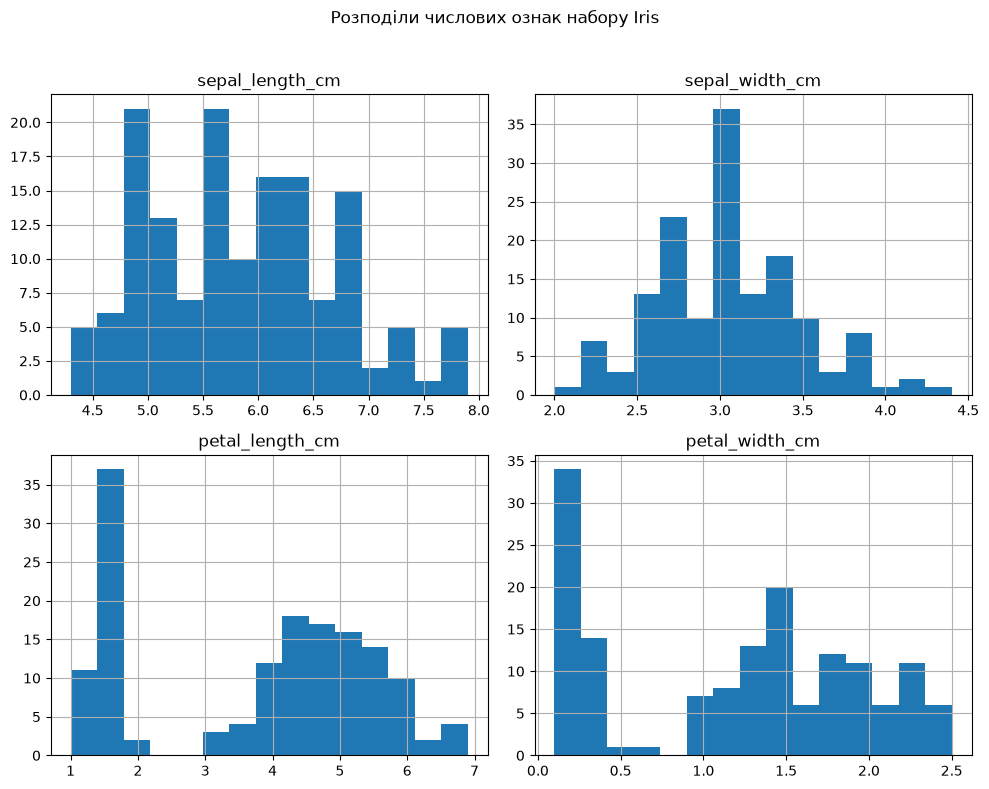

In [28]:
feature_columns = [
    "sepal_length_cm",
    "sepal_width_cm",
    "petal_length_cm",
    "petal_width_cm"
]

data[feature_columns].hist(
    bins=15,
    figsize=(10, 8)
)

plt.suptitle("Розподіли числових ознак набору Iris")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(FIGURES_DIR / "01_feature_histograms.png", dpi=150)
plt.show()

**Аналіз гістограм.**

1. **Найменші значення** має ширина пелюстки `petal_width_cm`: від 0,1 до 2,5 см, середнє ≈ 1,2 см.
2. **Найбільший діапазон** має довжина пелюстки `petal_length_cm`: від 1,0 до 6,9 см (розмах 5,9 см).
3. **Розподіли мають різну форму.** Ознаки чашолистка (`sepal_length_cm`, `sepal_width_cm`) не мають розривів і в цілому одновершинні (найближчий до симетричного дзвоноподібного — розподіл `sepal_width_cm`), тоді як розподіли ознак пелюстки мають дві чітко розділені групи з проміжком між ними.
4. **Кілька груп значень** помітно для `petal_length_cm` і `petal_width_cm`: окрема група малих значень (довжина до 2 см, ширина до 0,6 см) і основна група більших значень. Невелика група відповідає виду setosa.

### 7.1. Розподіл об'єктів за класами

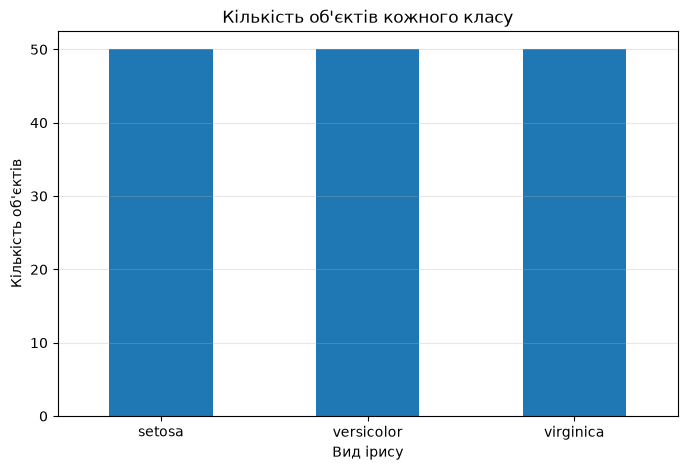

In [29]:
class_counts = data["species"].value_counts().sort_index()

class_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Кількість об'єктів кожного класу")
plt.xlabel("Вид ірису")
plt.ylabel("Кількість об'єктів")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.savefig(FIGURES_DIR / "02_class_counts.png", dpi=150, bbox_inches="tight")
plt.show()

**Чи є набір даних збалансованим?** Так. Кожен із трьох класів містить рівно 50 об'єктів (по 33,33 %), тобто набір ідеально збалансований.

### 7.2. Діаграма залежності двох ознак

Діаграма розсіювання показує, як розташовані об'єкти різних класів у площині двох ознак пелюстки.

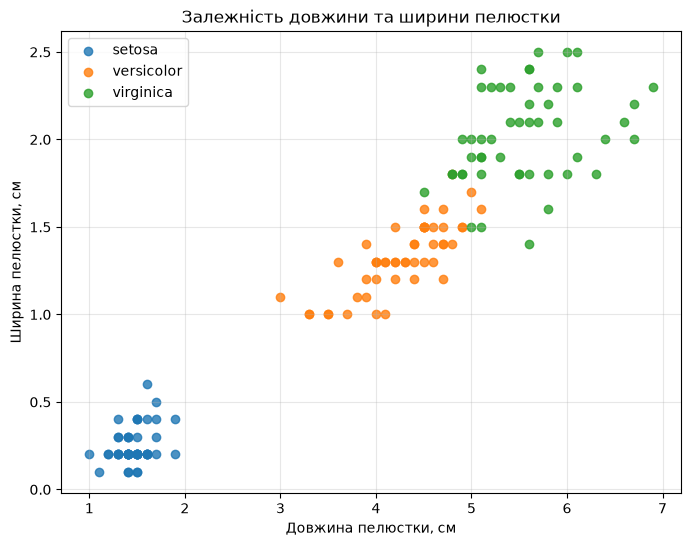

In [30]:
plt.figure(figsize=(8, 6))

# Кожен вид малюємо окремим кольором, щоб побачити групи
for species_name, group in data.groupby("species"):
    plt.scatter(
        group["petal_length_cm"],
        group["petal_width_cm"],
        label=species_name,
        alpha=0.8
    )

plt.title("Залежність довжини та ширини пелюстки")
plt.xlabel("Довжина пелюстки, см")
plt.ylabel("Ширина пелюстки, см")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(FIGURES_DIR / "03_petal_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

**Аналіз діаграми.**

1. Так, об'єкти різних класів утворюють окремі групи (кластери), а довжина і ширина пелюстки мають сильну пряму залежність.
2. Найкраще відокремлюється клас **setosa** — його точки розташовані в лівому нижньому куті (довжина пелюстки < 2 см) з великим проміжком до інших класів.
3. Частково перекриваються класи **versicolor** і **virginica** — у зоні довжини пелюстки ≈ 4,5–5,1 см і ширини ≈ 1,4–1,8 см.
4. Так, ознаки пелюстки дуже інформативні: setosa розпізнається безпомилково навіть за однією ознакою, а versicolor і virginica розділяються з невеликою кількістю помилок у зоні перекриття.

## 8. Постановка задачі машинного навчання

### Об'єкт дослідження

Одним об'єктом є одна квітка ірису, для якої виміряно
характеристики чашолистка та пелюстки.

### Ознаки

Використовуються чотири числові ознаки:

1. довжина чашолистка;
2. ширина чашолистка;
3. довжина пелюстки;
4. ширина пелюстки.

### Цільова змінна

Цільовою змінною є `species` – вид квітки ірису.

### Тип задачі

Задача належить до навчання з учителем і є задачею
багатокласової класифікації.

### Формулювання задачі

Необхідно за чотирма числовими характеристиками квітки
автоматично визначити, до якого з трьох видів ірису вона належить:
setosa, versicolor або virginica.

### 8.1. Програмне розділення ознак і цільової змінної

Моделі на цьому етапі ще не навчаються — лише показано, як виділяються матриця ознак `X` і вектор цільової змінної `y`.

In [31]:
X = data.drop(columns=["species"])
y = data["species"]

print("Розмір матриці ознак X:", X.shape)
print("Розмір цільової змінної y:", y.shape)

Розмір матриці ознак X: (150, 4)
Розмір цільової змінної y: (150,)


In [32]:
display(X.head())

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [33]:
display(y.head())

0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: str

### 8.2. Автоматична перевірка правильності результату

In [34]:
expected_columns = {
    "sepal_length_cm",
    "sepal_width_cm",
    "petal_length_cm",
    "petal_width_cm",
    "species"
}

assert data.shape == (150, 5), (
    f"Очікувався розмір (150, 5), отримано {data.shape}"
)

assert set(data.columns) == expected_columns, (
    "Назви стовпців не відповідають очікуваним."
)

assert data.isna().sum().sum() == 0, (
    "У таблиці знайдено пропущені значення."
)

assert data["species"].nunique() == 3, (
    "Очікувалося три класи."
)

assert set(data["species"].unique()) == {
    "setosa",
    "versicolor",
    "virginica"
}, "Назви класів не відповідають очікуваним."

print("Усі основні перевірки виконано успішно.")

Усі основні перевірки виконано успішно.


## 9. Додаткові завдання

### Варіант 1. Додаткова діаграма

Залежність довжини чашолистка від його ширини для трьох видів ірису.

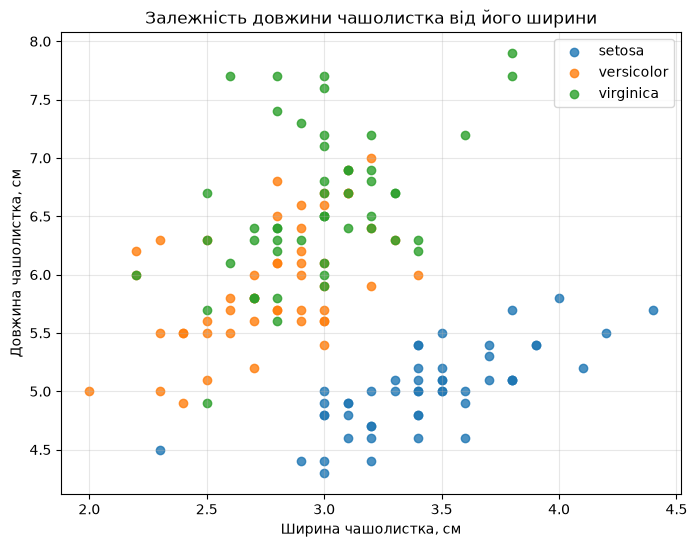

In [35]:
plt.figure(figsize=(8, 6))

for species_name, group in data.groupby("species"):
    plt.scatter(
        group["sepal_width_cm"],
        group["sepal_length_cm"],
        label=species_name,
        alpha=0.8
    )

plt.title("Залежність довжини чашолистка від його ширини")
plt.xlabel("Ширина чашолистка, см")
plt.ylabel("Довжина чашолистка, см")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(FIGURES_DIR / "04_sepal_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

За ознаками чашолистка добре відокремлюється лише setosa: її чашолистки короткі, але широкі (права нижня частина діаграми).
Точки versicolor і virginica значно перемішані, тому ознаки чашолистка менш інформативні, ніж ознаки пелюстки.

### Варіант 2. Власна функція

In [36]:
def dataset_summary(dataset):
    """
    Виводить коротку інформацію про набір даних.
    """
    print("Кількість рядків:", dataset.shape[0])
    print("Кількість стовпців:", dataset.shape[1])
    print("Кількість пропусків:", dataset.isna().sum().sum())
    print("Кількість дублікатів:", dataset.duplicated().sum())


dataset_summary(data)

Кількість рядків: 150
Кількість стовпців: 5
Кількість пропусків: 0
Кількість дублікатів: 1


### Варіант 3. Збереження статистики

In [37]:
STATISTICS_PATH = REPORTS_DIR / "iris_statistics.csv"

data.describe().T.to_csv(STATISTICS_PATH)

print("Статистику збережено:", STATISTICS_PATH)

Статистику збережено: C:\Users\gilbert\Documents\university\4kurs\РОіКМН\pattern-recognition-practice\reports\iris_statistics.csv


# Висновки

Під час виконання практичної роботи було створено GitHub-репозиторій
для зберігання матеріалів курсу та сформовано базову структуру
ML-проєкту (папки `notebooks`, `data`, `reports`, файли `README.md` і `.gitignore`).

У середовищі Google Colab було підключено бібліотеки NumPy, pandas,
Matplotlib і scikit-learn, а також підключено Google Drive.

Для дослідження використано набір даних Iris, який містить 150
об'єктів, чотири числові ознаки та одну цільову категоріальну змінну.
Об'єктом дослідження є квітка ірису, а цільовою змінною – її вид.

Під час первинного аналізу було визначено розмір таблиці, назви
стовпців, типи даних, кількість пропущених значень і основні
статистичні характеристики. Також було побудовано гістограми ознак,
діаграму кількості об'єктів кожного класу та діаграму залежності
довжини й ширини пелюстки.

Встановлено, що досліджувана задача є задачею багатокласової
класифікації: за чотирма числовими ознаками необхідно визначити
один із трьох видів ірису.

**Власні спостереження:**

- Пропущених значень у наборі немає; знайдено 1 повністю однаковий рядок, який не є помилкою даних.
- Класи ідеально збалансовані: по 50 об'єктів (33,33 %) у кожному з трьох видів.
- Найкраще розділяють класи ознаки пелюстки — `petal_length_cm` і `petal_width_cm`: їхні гістограми мають дві чітко відокремлені групи, а на діаграмі розсіювання види утворюють окремі кластери. Ознаки чашолистка розділяють класи значно гірше.
- Вид setosa відокремлюється повністю, а versicolor і virginica частково перекриваються на діаграмі залежності довжини й ширини пелюстки (довжина ≈ 4,5–5,1 см, ширина ≈ 1,4–1,8 см). Саме ці об'єкти будуть найскладнішими для майбутніх моделей класифікації.